In [1]:
# ============================================================
# RESTART UTILITIES - Iteration 2
# ============================================================

import os
import json
import glob
import shutil

DATA_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/By_Country/"
EMBEDDINGS_BASE_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2"
RESULTS_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2"
CHECKPOINT_FILE = "/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json"

def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"Processed combinations: {len(processed)}")
            print("\nCompleted:")
            for item in processed:
                # Handle both tuple formats: (model, dataset) or single values
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"  - {model:20s} → {dataset}")
                else:
                    print(f"  - {item}")
    else:
        print("No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f"  Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("All embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print("Embeddings directory doesn't exist")

def reset_results():
    """Delete all results"""
    if os.path.exists(RESULTS_DIR):
        response = input(f"  Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print("All results deleted")
        else:
            print("Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("="*60)
    print(" FULL RESET WARNING")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific model
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")


def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific dataset
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print("Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('modernbert-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print("RESTART UTILITIES LOADED")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\nTIP: To completely restart everything, run: complete_rerun()")

No checkpoint found - no progress yet

RESTART UTILITIES LOADED
Available functions:
  view_progress()              - See what's completed
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

TIP: To completely restart everything, run: complete_rerun()


In [2]:
complete_rerun()


 COMPLETE RERUN
This will:
  1. Clear checkpoint file
  2. Delete all embeddings
  3. Delete all results
  4. Start fresh from beginning
 Embeddings deleted
 Results deleted

 COMPLETE RERUN READY
Now run the main pipeline cell to start fresh!


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Found 9 total datasets
Skipping 4 datasets:
 RW_ACTUALS_Hungary.csv
 RW_ACTUALS_International.csv
 RW_ACTUALS_Russia.csv
 RW_ACTUALS_UAE.csv

Processing 5 datasets
Found 6 models to use
Total combinations: 30
Already processed: 0 combinations

################################################################################
MODEL: bert-base-cased (bert-base-cased)
################################################################################

Initializing bert-base-cased...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be

Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-cased

Processing: english | Model: bert-base-cased
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1774/1774 [00:56<00:00, 31.59it/s]


...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5213/5213 [05:28<00:00, 15.88it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/bert-base-cased/sweden_bert-base-cased_embeddings.pkl
Size: 63.47 MB

✗ ERROR processing sweden with bert-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: uk | Model: bert-base-cased
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using d

Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1755/1755 [02:51<00:00, 10.22it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/bert-base-cased/uk_bert-base-cased_embeddings.pkl
Size: 22.88 MB

✗ ERROR processing uk with bert-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


PHASE 2: TRAINING SVM - bert-base-cased

Training SVM: ENGLISH | Model: bert-base-cased
Training samples: 5675
Test samples: 1419

Training LinearSVC (max 300s)...
Training completed in 9.51s

Accuracy: 0.7963
F1 Score (weighted): 0.8003
F1 Score (macro): 0.7753

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8826    0.8087    0.8440       967
    Process Safety     0.6529    0.7699    0.7066       452

          accuracy                         0

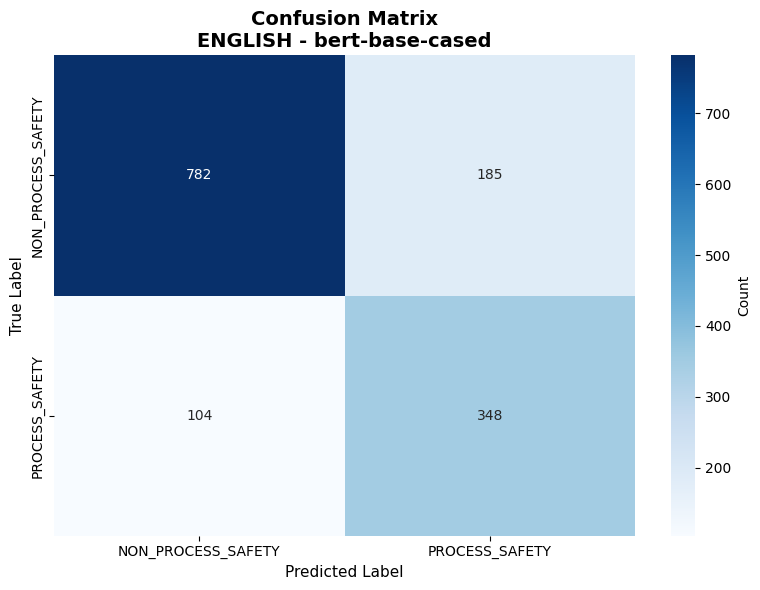


Training SVM: GERMANY | Model: bert-base-cased
Training samples: 18268
Test samples: 4568

Training LinearSVC (max 300s)...
Training completed in 57.40s

Accuracy: 0.7631
F1 Score (weighted): 0.7995
F1 Score (macro): 0.6359

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9523    0.7694    0.8511      4020
    Process Safety     0.2977    0.7172    0.4208       548

          accuracy                         0.7631      4568
         macro avg     0.6250    0.7433    0.6359      4568
      weighted avg     0.8738    0.7631    0.7995      4568


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_germany_bert_base_cased.png


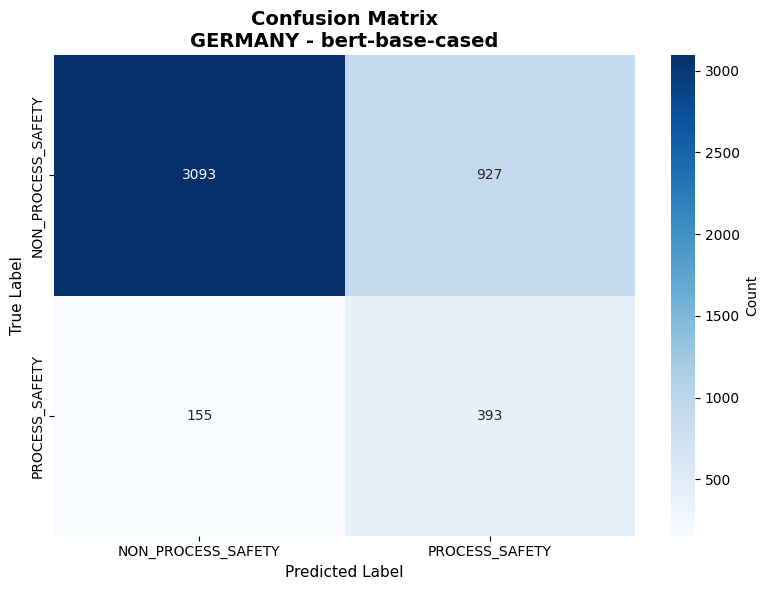


Training SVM: NETHERLANDS | Model: bert-base-cased
Training samples: 2534
Test samples: 634

Training LinearSVC (max 300s)...
Training completed in 3.61s

Accuracy: 0.7571
F1 Score (weighted): 0.7623
F1 Score (macro): 0.7314

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8557    0.7770    0.8145       435
    Process Safety     0.5941    0.7136    0.6484       199

          accuracy                         0.7571       634
         macro avg     0.7249    0.7453    0.7314       634
      weighted avg     0.7736    0.7571    0.7623       634


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_netherlands_bert_base_cased.png


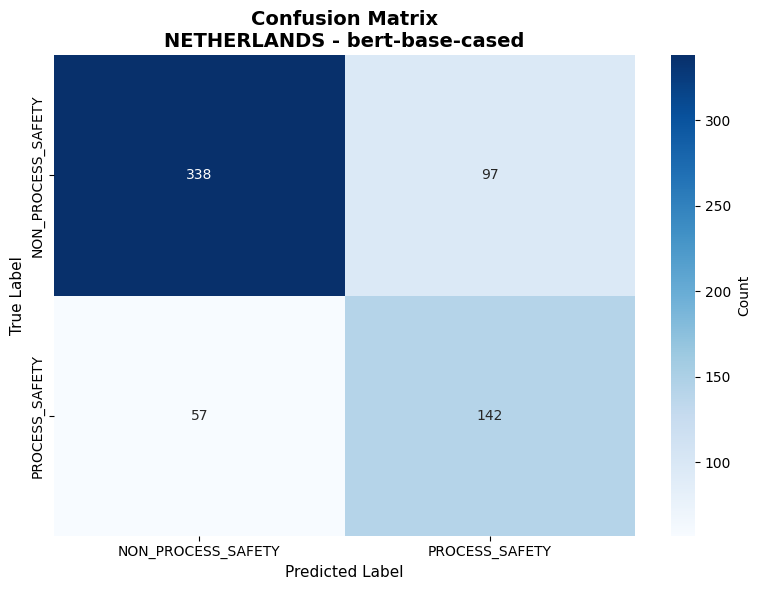


Training SVM: SWEDEN | Model: bert-base-cased
Training samples: 16680
Test samples: 4171

Training LinearSVC (max 300s)...
Training completed in 43.23s

Accuracy: 0.7938
F1 Score (weighted): 0.8405
F1 Score (macro): 0.6077

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9779    0.7965    0.8779      3882
    Process Safety     0.2170    0.7578    0.3374       289

          accuracy                         0.7938      4171
         macro avg     0.5975    0.7771    0.6077      4171
      weighted avg     0.9251    0.7938    0.8405      4171


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_sweden_bert_base_cased.png


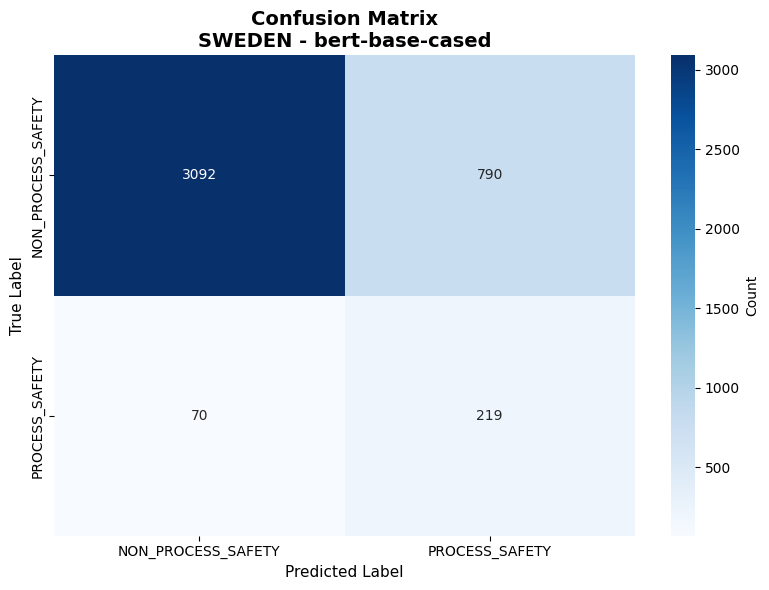


Training SVM: UK | Model: bert-base-cased
Training samples: 5615
Test samples: 1404

Training LinearSVC (max 300s)...
Training completed in 11.42s

Accuracy: 0.7863
F1 Score (weighted): 0.7908
F1 Score (macro): 0.7638

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8779    0.7994    0.8368       962
    Process Safety     0.6345    0.7579    0.6907       442

          accuracy                         0.7863      1404
         macro avg     0.7562    0.7786    0.7638      1404
      weighted avg     0.8012    0.7863    0.7908      1404


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_uk_bert_base_cased.png


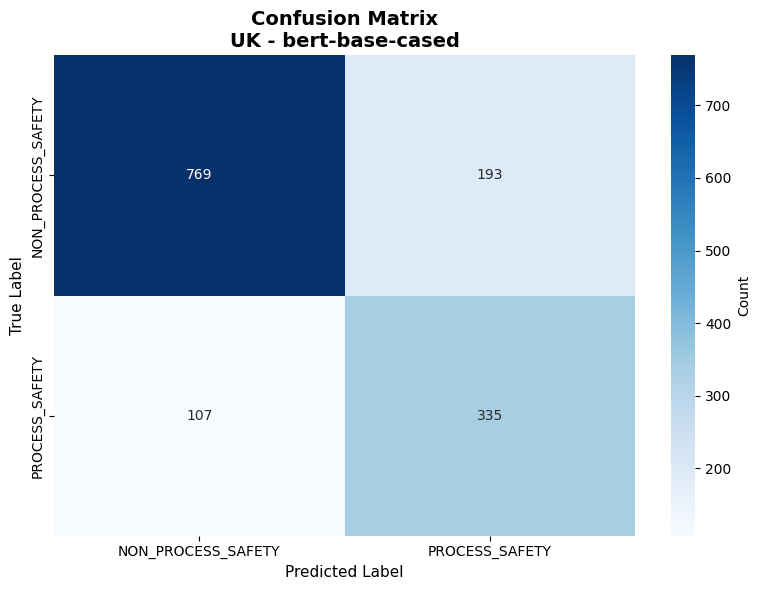


 Processing complete bert-base-cased

################################################################################
MODEL: bert-large-cased (bert-large-cased)
################################################################################

Initializing bert-large-cased...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-large-cased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to b

Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-large-cased

Processing: english | Model: bert-large-cased
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1774/1774 [04:15<00:00,  6.95it/s]



Training set: (5675, 1024)
Test set: (1419, 1024)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/bert-large-cased/english_bert-large-cased_embeddings.pkl
Size: 30.07 MB

✗ ERROR processing english with bert-large-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: germany | Model: bert-large-cased
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating bert-large-cased

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5213/5213 [11:02<00:00,  7.87it/s]



Training set: (16680, 1024)
Test set: (4171, 1024)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/bert-large-cased/sweden_bert-large-cased_embeddings.pkl
Size: 83.83 MB

✗ ERROR processing sweden with bert-large-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: uk | Model: bert-large-cased
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating bert-large-cased embeddings...


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1755/1755 [04:50<00:00,  6.03it/s]



Training set: (5615, 1024)
Test set: (1404, 1024)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/bert-large-cased/uk_bert-large-cased_embeddings.pkl
Size: 29.73 MB

✗ ERROR processing uk with bert-large-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


PHASE 2: TRAINING SVM - bert-large-cased

Training SVM: ENGLISH | Model: bert-large-cased
Training samples: 5675
Test samples: 1419

Training LinearSVC (max 300s)...
Training completed in 17.81s

Accuracy: 0.7837
F1 Score (weighted): 0.7879
F1 Score (macro): 0.7616

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8733    0.7983    0.8341       967
    Process Safety     0.6355    0.7522    0.6890       452

          accuracy                  

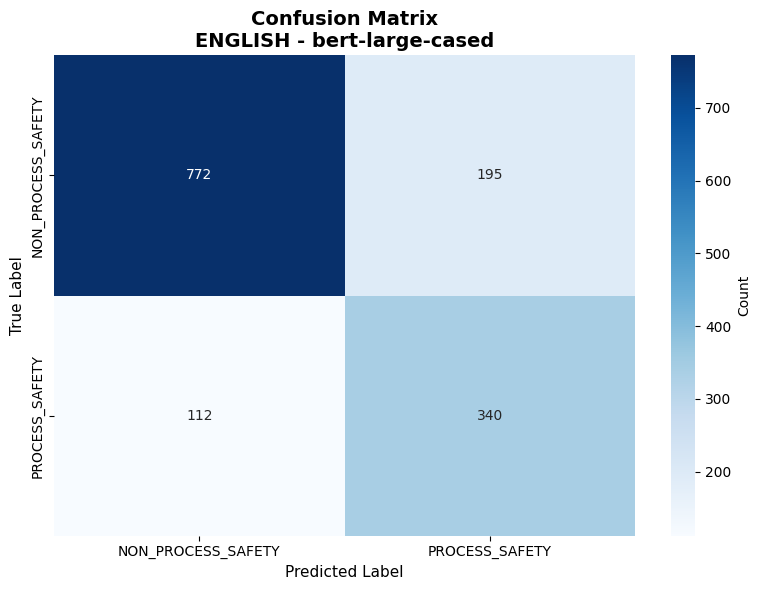


Training SVM: GERMANY | Model: bert-large-cased
Training samples: 18268
Test samples: 4568

Training LinearSVC (max 300s)...
Training completed in 209.82s

Accuracy: 0.7813
F1 Score (weighted): 0.8140
F1 Score (macro): 0.6574

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9584    0.7856    0.8634      4020
    Process Safety     0.3229    0.7500    0.4514       548

          accuracy                         0.7813      4568
         macro avg     0.6406    0.7678    0.6574      4568
      weighted avg     0.8822    0.7813    0.8140      4568


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_germany_bert_large_cased.png


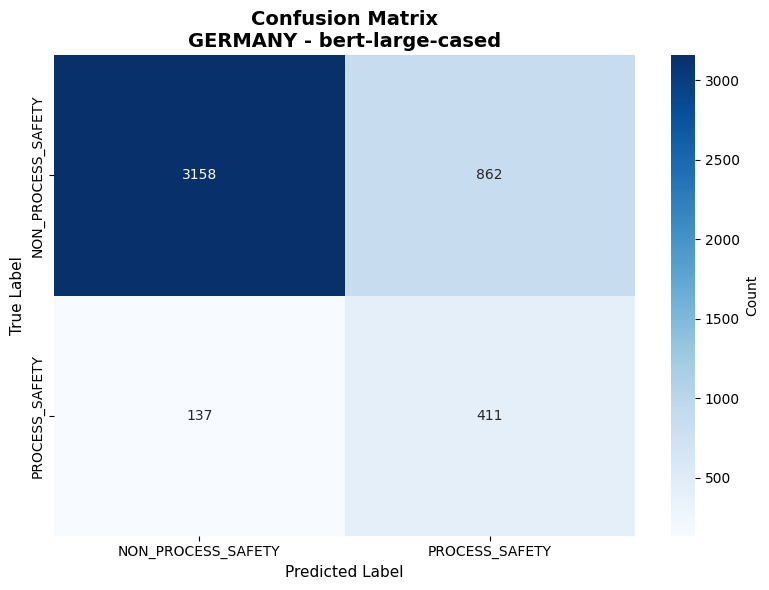


Training SVM: NETHERLANDS | Model: bert-large-cased
Training samples: 2534
Test samples: 634

Training LinearSVC (max 300s)...
Training completed in 9.74s

Accuracy: 0.8186
F1 Score (weighted): 0.8224
F1 Score (macro): 0.7992

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9040    0.8230    0.8616       435
    Process Safety     0.6765    0.8090    0.7368       199

          accuracy                         0.8186       634
         macro avg     0.7903    0.8160    0.7992       634
      weighted avg     0.8326    0.8186    0.8224       634


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_netherlands_bert_large_cased.png


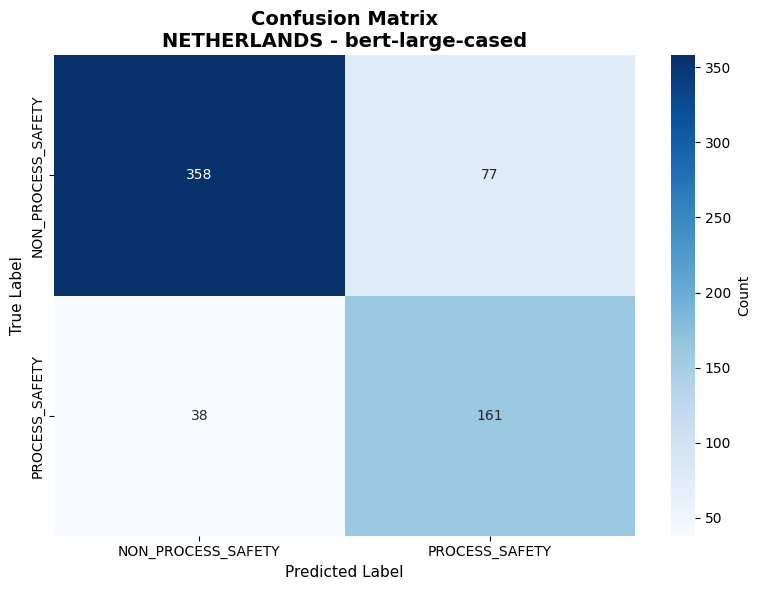


Training SVM: SWEDEN | Model: bert-large-cased
Training samples: 16680
Test samples: 4171

Training LinearSVC (max 300s)...
Training completed in 43.12s

Accuracy: 0.8118
F1 Score (weighted): 0.8527
F1 Score (macro): 0.6219

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9772    0.8168    0.8899      3882
    Process Safety     0.2322    0.7439    0.3539       289

          accuracy                         0.8118      4171
         macro avg     0.6047    0.7804    0.6219      4171
      weighted avg     0.9256    0.8118    0.8527      4171


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_sweden_bert_large_cased.png


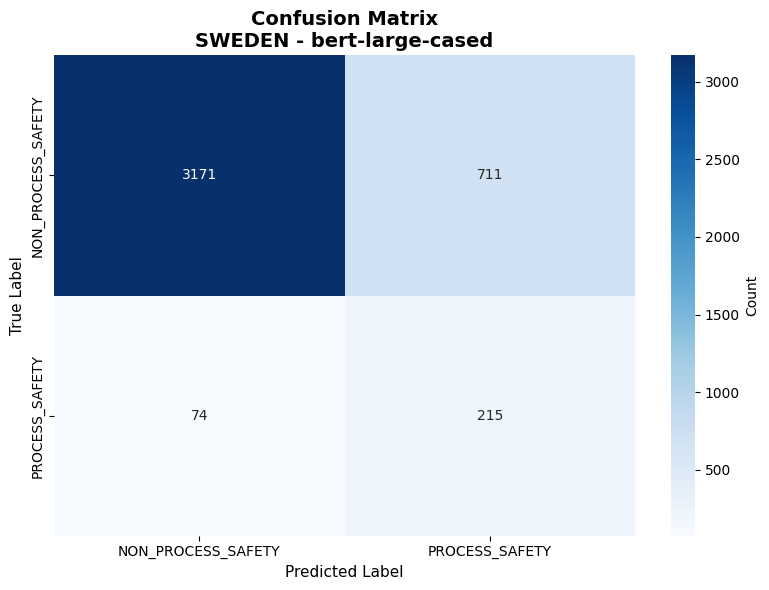


Training SVM: UK | Model: bert-large-cased
Training samples: 5615
Test samples: 1404

Training LinearSVC (max 300s)...
Training completed in 7.10s

Accuracy: 0.7906
F1 Score (weighted): 0.7951
F1 Score (macro): 0.7689

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8830    0.8004    0.8397       962
    Process Safety     0.6391    0.7692    0.6982       442

          accuracy                         0.7906      1404
         macro avg     0.7611    0.7848    0.7689      1404
      weighted avg     0.8062    0.7906    0.7951      1404


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_uk_bert_large_cased.png


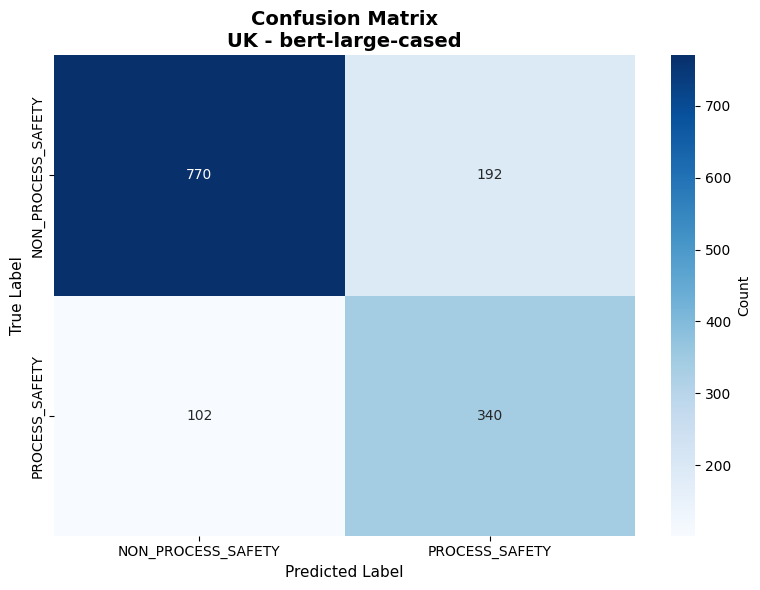


 Processing complete bert-large-cased

################################################################################
MODEL: roberta-base (roberta-base)
################################################################################

Initializing roberta-base...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.dense.weight', 'lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of 

Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - roberta-base

Processing: english | Model: roberta-base
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1774/1774 [01:43<00:00, 17.18it/s]



Training set: (5675, 768)
Test set: (1419, 768)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/roberta-base/english_roberta-base_embeddings.pkl
Size: 23.15 MB

✗ ERROR processing english with roberta-base: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: germany | Model: roberta-base
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating roberta-base embeddings...
Using d

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5213/5213 [07:01<00:00, 12.38it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/roberta-base/sweden_roberta-base_embeddings.pkl
Size: 63.47 MB

✗ ERROR processing sweden with roberta-base: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: uk | Model: roberta-base
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1755/1755 [02:10<00:00, 13.46it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/roberta-base/uk_roberta-base_embeddings.pkl
Size: 22.88 MB

✗ ERROR processing uk with roberta-base: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


PHASE 2: TRAINING SVM - roberta-base

Training SVM: ENGLISH | Model: roberta-base
Training samples: 5675
Test samples: 1419

Training LinearSVC (max 300s)...
Training completed in 4.35s

Accuracy: 0.8041
F1 Score (weighted): 0.8080
F1 Score (macro): 0.7842

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8901    0.8128    0.8497       967
    Process Safety     0.6623    0.7854    0.7186       452

          accuracy                         0.8041      1419

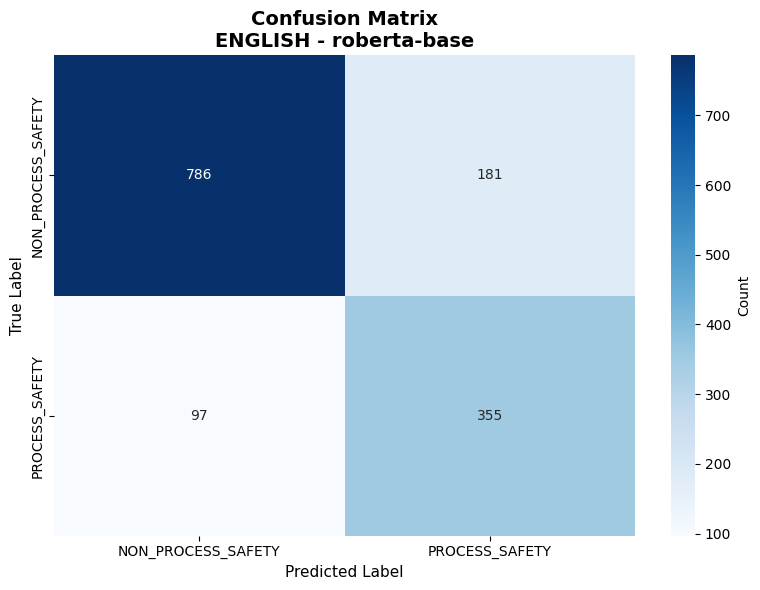


Training SVM: GERMANY | Model: roberta-base
Training samples: 18268
Test samples: 4568

Training LinearSVC (max 300s)...
Training completed in 18.63s

Accuracy: 0.7712
F1 Score (weighted): 0.8060
F1 Score (macro): 0.6460

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9556    0.7761    0.8566      4020
    Process Safety     0.3093    0.7354    0.4354       548

          accuracy                         0.7712      4568
         macro avg     0.6324    0.7558    0.6460      4568
      weighted avg     0.8781    0.7712    0.8060      4568


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_germany_roberta_base.png


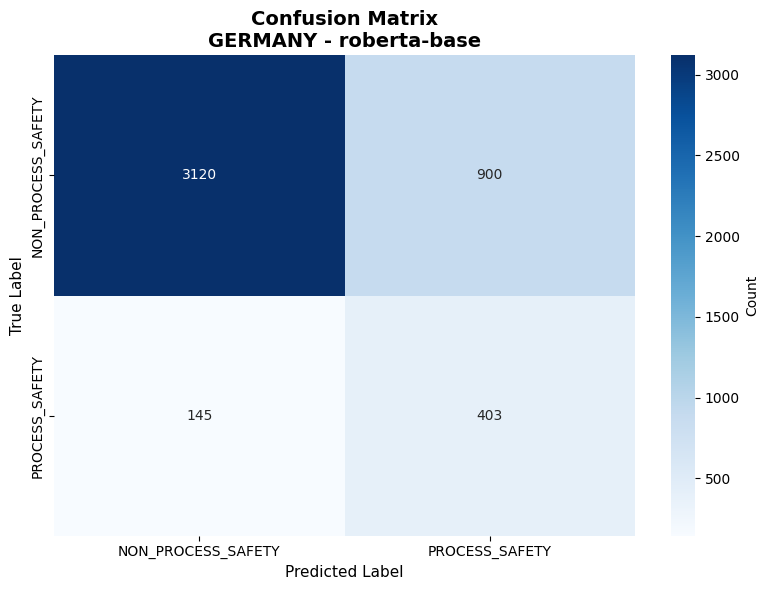


Training SVM: NETHERLANDS | Model: roberta-base
Training samples: 2534
Test samples: 634

Training LinearSVC (max 300s)...
Training completed in 1.37s

Accuracy: 0.7003
F1 Score (weighted): 0.7093
F1 Score (macro): 0.6771

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8320    0.7057    0.7637       435
    Process Safety     0.5170    0.6884    0.5905       199

          accuracy                         0.7003       634
         macro avg     0.6745    0.6971    0.6771       634
      weighted avg     0.7331    0.7003    0.7093       634


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_netherlands_roberta_base.png


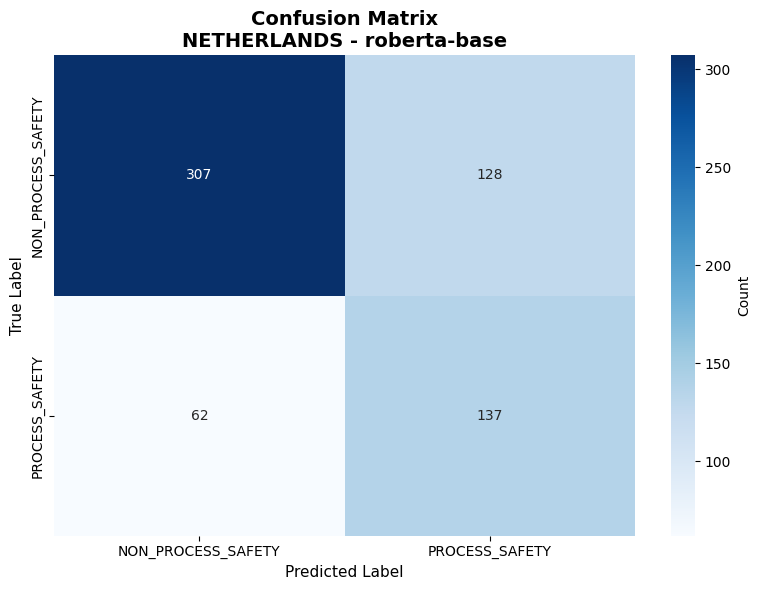


Training SVM: SWEDEN | Model: roberta-base
Training samples: 16680
Test samples: 4171

Training LinearSVC (max 300s)...
Training completed in 12.34s

Accuracy: 0.7698
F1 Score (weighted): 0.8237
F1 Score (macro): 0.5871

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9768    0.7710    0.8618      3882
    Process Safety     0.1969    0.7543    0.3123       289

          accuracy                         0.7698      4171
         macro avg     0.5869    0.7627    0.5871      4171
      weighted avg     0.9228    0.7698    0.8237      4171


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_sweden_roberta_base.png


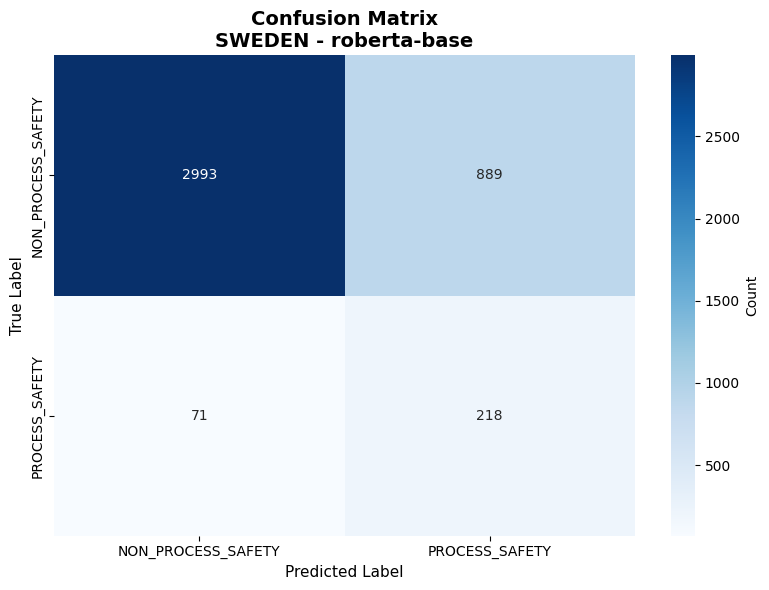


Training SVM: UK | Model: roberta-base
Training samples: 5615
Test samples: 1404

Training LinearSVC (max 300s)...
Training completed in 2.49s

Accuracy: 0.8070
F1 Score (weighted): 0.8108
F1 Score (macro): 0.7861

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8922    0.8170    0.8530       962
    Process Safety     0.6635    0.7851    0.7192       442

          accuracy                         0.8070      1404
         macro avg     0.7778    0.8011    0.7861      1404
      weighted avg     0.8202    0.8070    0.8108      1404


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_uk_roberta_base.png


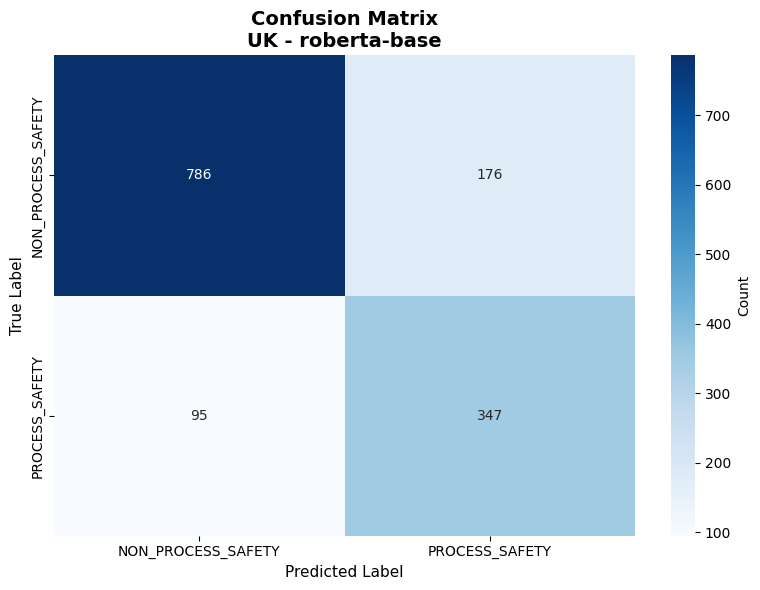


 Processing complete roberta-base

################################################################################
MODEL: roberta-large (roberta-large)
################################################################################

Initializing roberta-large...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at roberta-large were not used when initializing RobertaModel: ['lm_head.dense.weight', 'lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of

Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - roberta-large

Processing: english | Model: roberta-large
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating roberta-large embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1774/1774 [04:02<00:00,  7.33it/s]



Training set: (5675, 1024)
Test set: (1419, 1024)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/roberta-large/english_roberta-large_embeddings.pkl
Size: 30.07 MB

✗ ERROR processing english with roberta-large: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: germany | Model: roberta-large
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating roberta-large embeddings...


...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating roberta-large embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5213/5213 [07:36<00:00, 11.42it/s]



Training set: (16680, 1024)
Test set: (4171, 1024)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/roberta-large/sweden_roberta-large_embeddings.pkl
Size: 83.83 MB

✗ ERROR processing sweden with roberta-large: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: uk | Model: roberta-large
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating roberta-large embeddings...
Using device: c

Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1755/1755 [03:42<00:00,  7.88it/s]



Training set: (5615, 1024)
Test set: (1404, 1024)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/roberta-large/uk_roberta-large_embeddings.pkl
Size: 29.73 MB

✗ ERROR processing uk with roberta-large: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


PHASE 2: TRAINING SVM - roberta-large

Training SVM: ENGLISH | Model: roberta-large
Training samples: 5675
Test samples: 1419

Training LinearSVC (max 300s)...
Training completed in 15.23s

Accuracy: 0.8118
F1 Score (weighted): 0.8159
F1 Score (macro): 0.7936

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9005    0.8139    0.8550       967
    Process Safety     0.6697    0.8075    0.7322       452

          accuracy                         0.8118  

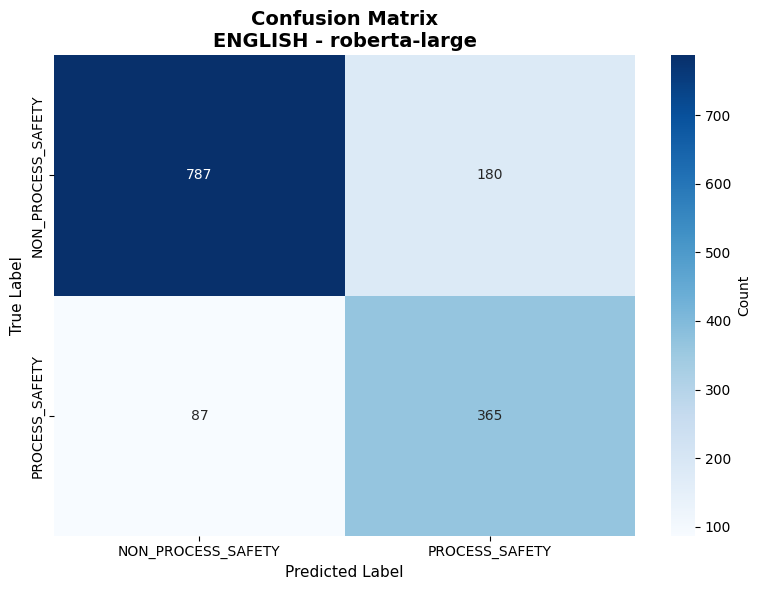


Training SVM: GERMANY | Model: roberta-large
Training samples: 18268
Test samples: 4568

Training LinearSVC (max 300s)...
Training completed in 77.69s

Accuracy: 0.8032
F1 Score (weighted): 0.8311
F1 Score (macro): 0.6813

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9626    0.8077    0.8784      4020
    Process Safety     0.3531    0.7701    0.4842       548

          accuracy                         0.8032      4568
         macro avg     0.6579    0.7889    0.6813      4568
      weighted avg     0.8895    0.8032    0.8311      4568


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_germany_roberta_large.png


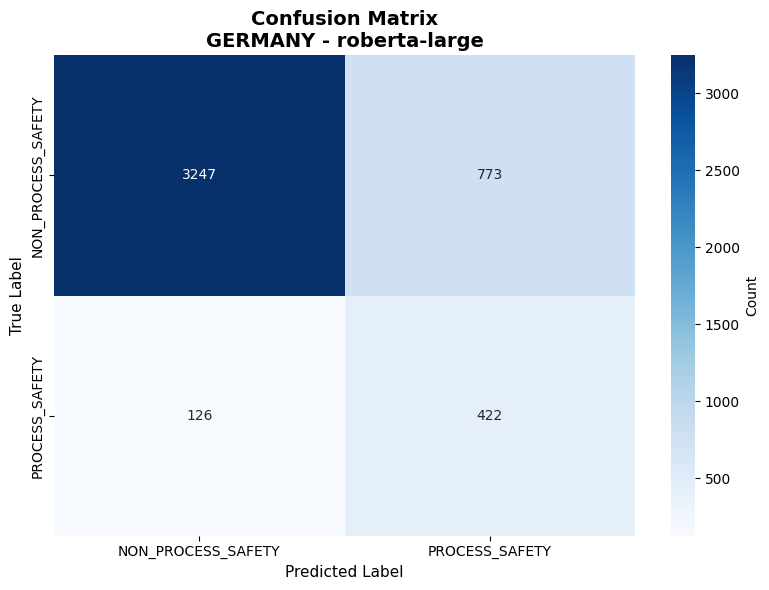


Training SVM: NETHERLANDS | Model: roberta-large
Training samples: 2534
Test samples: 634

Training LinearSVC (max 300s)...
Training completed in 6.06s

Accuracy: 0.7445
F1 Score (weighted): 0.7511
F1 Score (macro): 0.7210

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8564    0.7540    0.8020       435
    Process Safety     0.5737    0.7236    0.6400       199

          accuracy                         0.7445       634
         macro avg     0.7151    0.7388    0.7210       634
      weighted avg     0.7677    0.7445    0.7511       634


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_netherlands_roberta_large.png


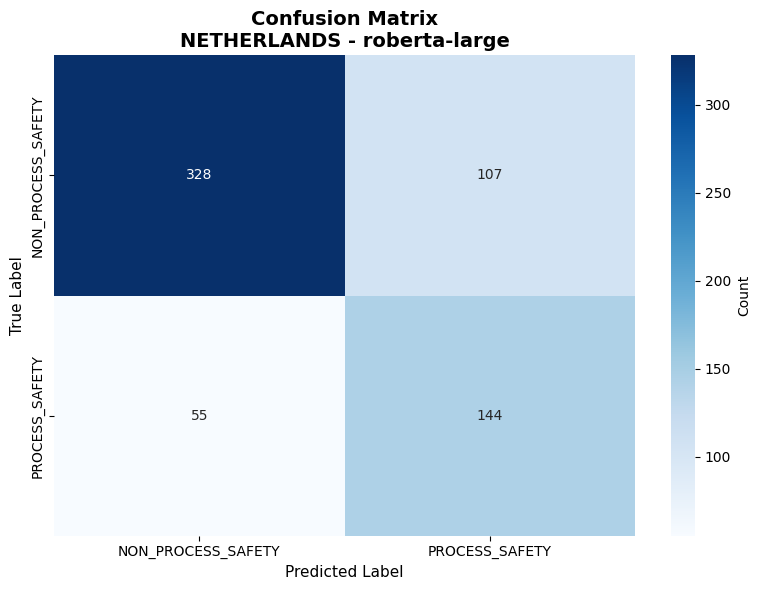


Training SVM: SWEDEN | Model: roberta-large
Training samples: 16680
Test samples: 4171

Training LinearSVC (max 300s)...
Training completed in 46.69s

Accuracy: 0.7921
F1 Score (weighted): 0.8391
F1 Score (macro): 0.6037

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9763    0.7960    0.8770      3882
    Process Safety     0.2127    0.7405    0.3305       289

          accuracy                         0.7921      4171
         macro avg     0.5945    0.7682    0.6037      4171
      weighted avg     0.9234    0.7921    0.8391      4171


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_sweden_roberta_large.png


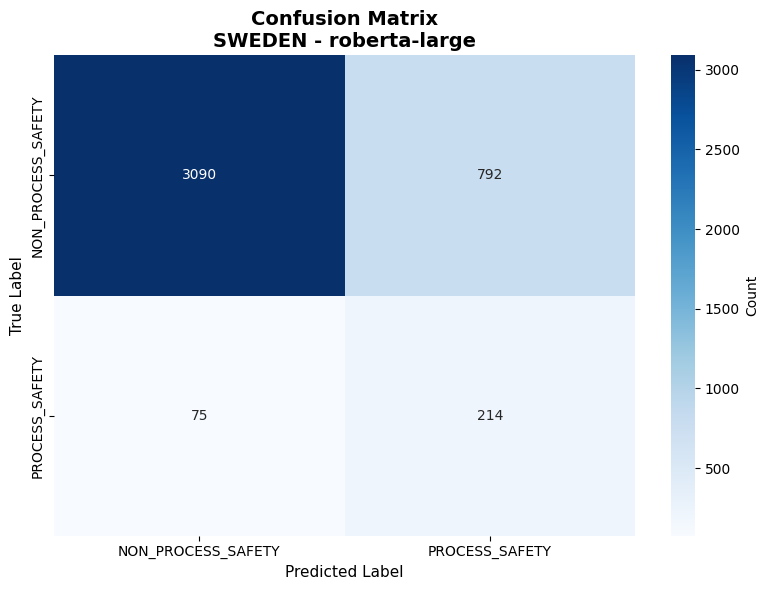


Training SVM: UK | Model: roberta-large
Training samples: 5615
Test samples: 1404

Training LinearSVC (max 300s)...
Training completed in 15.83s

Accuracy: 0.8077
F1 Score (weighted): 0.8122
F1 Score (macro): 0.7888

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9014    0.8077    0.8520       962
    Process Safety     0.6587    0.8077    0.7256       442

          accuracy                         0.8077      1404
         macro avg     0.7800    0.8077    0.7888      1404
      weighted avg     0.8250    0.8077    0.8122      1404


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_uk_roberta_large.png


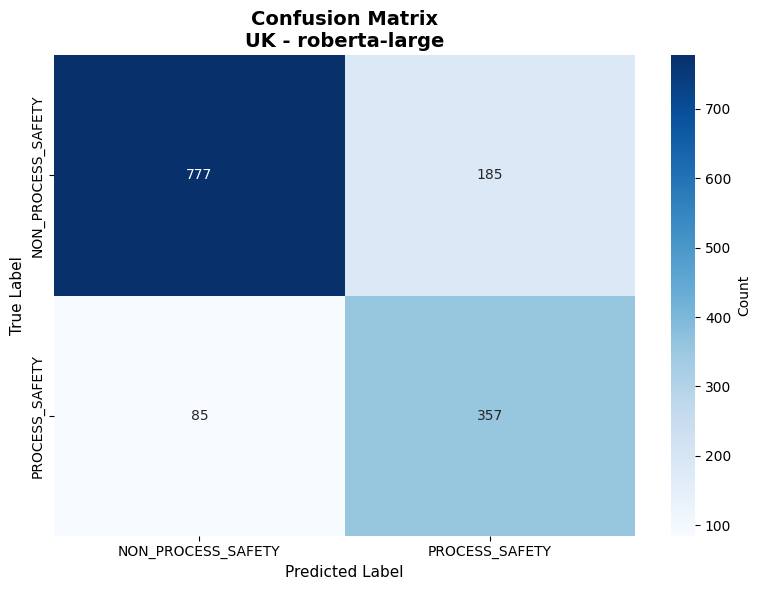


 Processing complete roberta-large

################################################################################
MODEL: distilbert-base-cased (distilbert-base-cased)
################################################################################

Initializing distilbert-base-cased...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at distilbert-base-cased were not used when initializing DistilBertModel: ['vocab_projector.bias', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassificatio

Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - distilbert-base-cased

Processing: english | Model: distilbert-base-cased
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating distilbert-base-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1774/1774 [01:35<00:00, 18.62it/s]



Training set: (5675, 768)
Test set: (1419, 768)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/distilbert-base-cased/english_distilbert-base-cased_embeddings.pkl
Size: 23.15 MB

✗ ERROR processing english with distilbert-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: germany | Model: distilbert-base-cased
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generatin

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating distilbert-base-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5213/5213 [02:46<00:00, 31.26it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/distilbert-base-cased/sweden_distilbert-base-cased_embeddings.pkl
Size: 63.47 MB

✗ ERROR processing sweden with distilbert-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: uk | Model: distilbert-base-cased
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating distilbert-ba

Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1755/1755 [01:01<00:00, 28.76it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/distilbert-base-cased/uk_distilbert-base-cased_embeddings.pkl
Size: 22.88 MB

✗ ERROR processing uk with distilbert-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


PHASE 2: TRAINING SVM - distilbert-base-cased

Training SVM: ENGLISH | Model: distilbert-base-cased
Training samples: 5675
Test samples: 1419

Training LinearSVC (max 300s)...
Training completed in 6.63s

Accuracy: 0.8020
F1 Score (weighted): 0.8063
F1 Score (macro): 0.7830

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8933    0.8056    0.8472       967
    Process Safety     0.6563    0.7942    0.7187       452

          accu

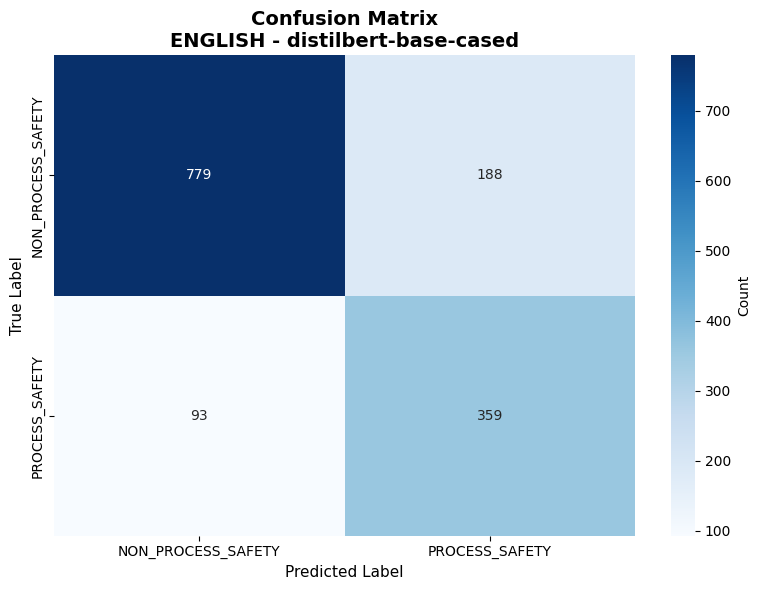


Training SVM: GERMANY | Model: distilbert-base-cased
Training samples: 18268
Test samples: 4568

Training LinearSVC (max 300s)...
Training completed in 28.35s

Accuracy: 0.7874
F1 Score (weighted): 0.8185
F1 Score (macro): 0.6617

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9574    0.7938    0.8679      4020
    Process Safety     0.3287    0.7409    0.4554       548

          accuracy                         0.7874      4568
         macro avg     0.6431    0.7673    0.6617      4568
      weighted avg     0.8820    0.7874    0.8185      4568


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_germany_distilbert_base_cased.png


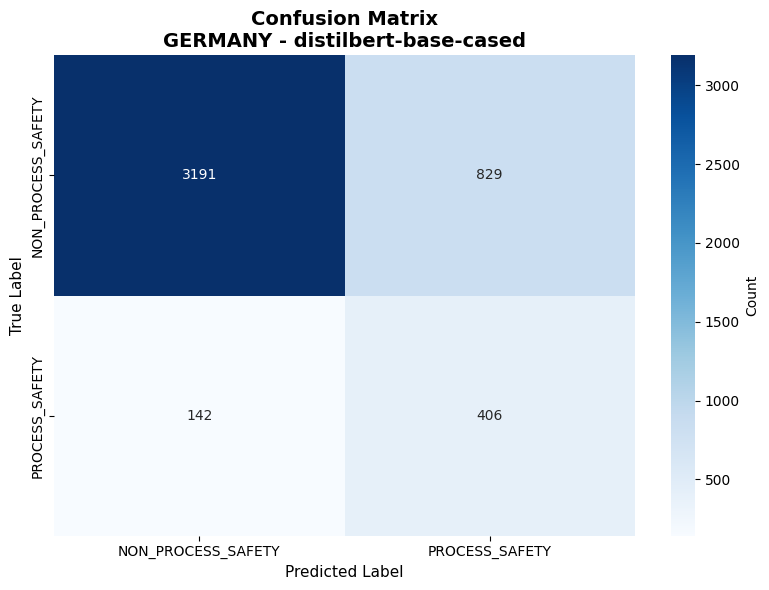


Training SVM: NETHERLANDS | Model: distilbert-base-cased
Training samples: 2534
Test samples: 634

Training LinearSVC (max 300s)...
Training completed in 1.76s

Accuracy: 0.7445
F1 Score (weighted): 0.7500
F1 Score (macro): 0.7175

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8456    0.7678    0.8048       435
    Process Safety     0.5774    0.6935    0.6301       199

          accuracy                         0.7445       634
         macro avg     0.7115    0.7306    0.7175       634
      weighted avg     0.7614    0.7445    0.7500       634


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_netherlands_distilbert_base_cased.png


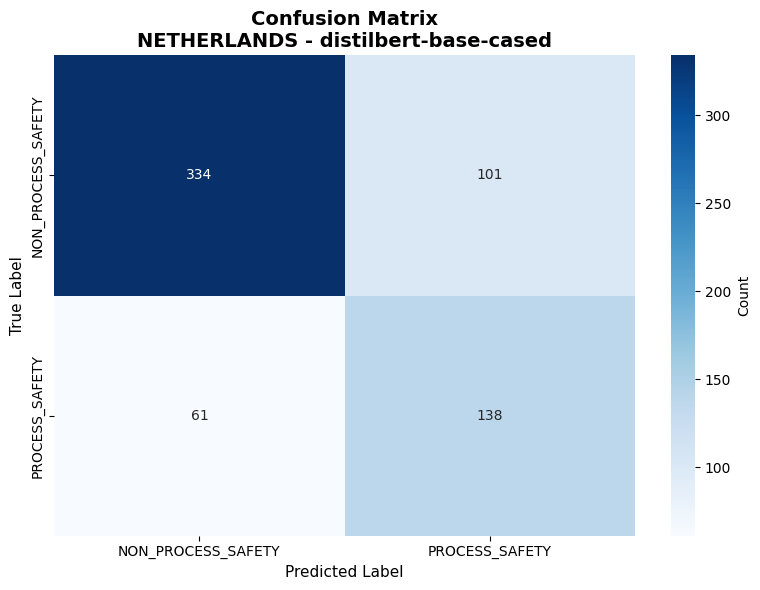


Training SVM: SWEDEN | Model: distilbert-base-cased
Training samples: 16680
Test samples: 4171

Training LinearSVC (max 300s)...
Training completed in 28.10s

Accuracy: 0.7974
F1 Score (weighted): 0.8427
F1 Score (macro): 0.6073

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9759    0.8022    0.8805      3882
    Process Safety     0.2163    0.7336    0.3341       289

          accuracy                         0.7974      4171
         macro avg     0.5961    0.7679    0.6073      4171
      weighted avg     0.9232    0.7974    0.8427      4171


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_sweden_distilbert_base_cased.png


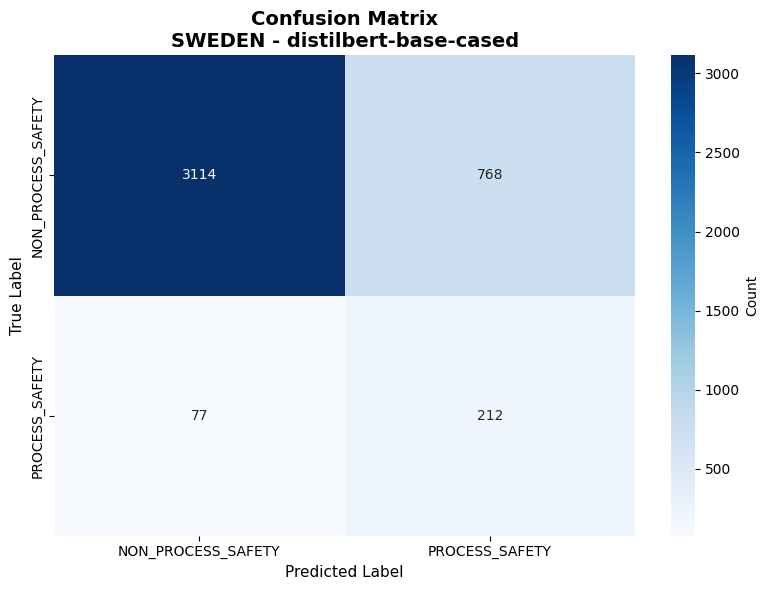


Training SVM: UK | Model: distilbert-base-cased
Training samples: 5615
Test samples: 1404

Training LinearSVC (max 300s)...
Training completed in 7.08s

Accuracy: 0.8041
F1 Score (weighted): 0.8083
F1 Score (macro): 0.7835

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8926    0.8119    0.8503       962
    Process Safety     0.6578    0.7873    0.7168       442

          accuracy                         0.8041      1404
         macro avg     0.7752    0.7996    0.7835      1404
      weighted avg     0.8187    0.8041    0.8083      1404


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_uk_distilbert_base_cased.png


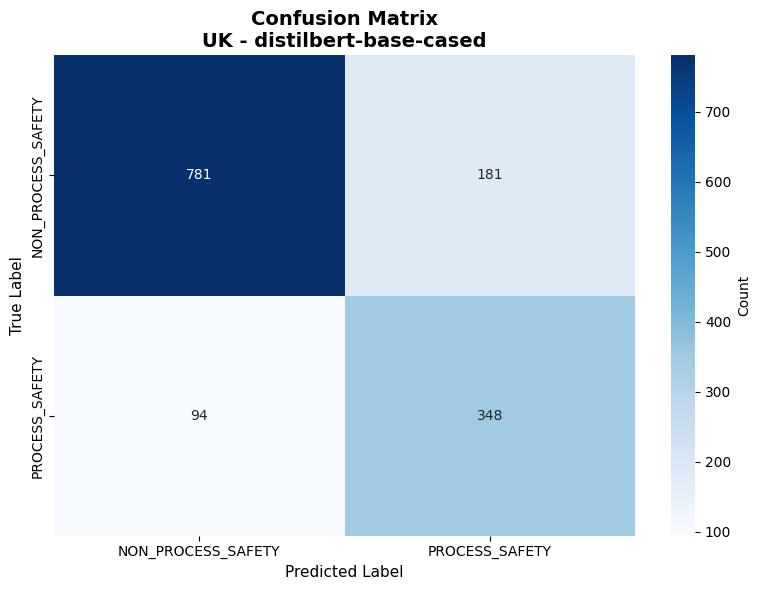


 Processing complete distilbert-base-cased

################################################################################
MODEL: xlnet-base-cased (xlnet-base-cased)
################################################################################

Initializing xlnet-base-cased...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at xlnet-base-cased were not used when initializing XLNetModel: ['lm_loss.weight', 'lm_loss.bias']
- This IS expected if you are initializing XLNetModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLNetModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - xlnet-base-cased

Processing: english | Model: xlnet-base-cased
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating xlnet-base-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1774/1774 [06:05<00:00,  4.85it/s]



Training set: (5675, 768)
Test set: (1419, 768)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/xlnet-base-cased/english_xlnet-base-cased_embeddings.pkl
Size: 23.15 MB

✗ ERROR processing english with xlnet-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: germany | Model: xlnet-base-cased
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating xlnet-base-cased e

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating xlnet-base-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5213/5213 [15:09<00:00,  5.73it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/xlnet-base-cased/sweden_xlnet-base-cased_embeddings.pkl
Size: 63.47 MB

✗ ERROR processing sweden with xlnet-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


Processing: uk | Model: xlnet-base-cased
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating xlnet-base-cased embeddings...
Us

Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1755/1755 [05:57<00:00,  4.91it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2/xlnet-base-cased/uk_xlnet-base-cased_embeddings.pkl
Size: 22.88 MB

✗ ERROR processing uk with xlnet-base-cased: [Errno 2] No such file or directory: '/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json'


PHASE 2: TRAINING SVM - xlnet-base-cased

Training SVM: ENGLISH | Model: xlnet-base-cased
Training samples: 5675
Test samples: 1419

Training LinearSVC (max 300s)...
Training completed in 12.40s

Accuracy: 0.7223
F1 Score (weighted): 0.7304
F1 Score (macro): 0.7027

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8507    0.7187    0.7791       967
    Process Safety     0.5482    0.7301    0.6262       452

          accuracy                    

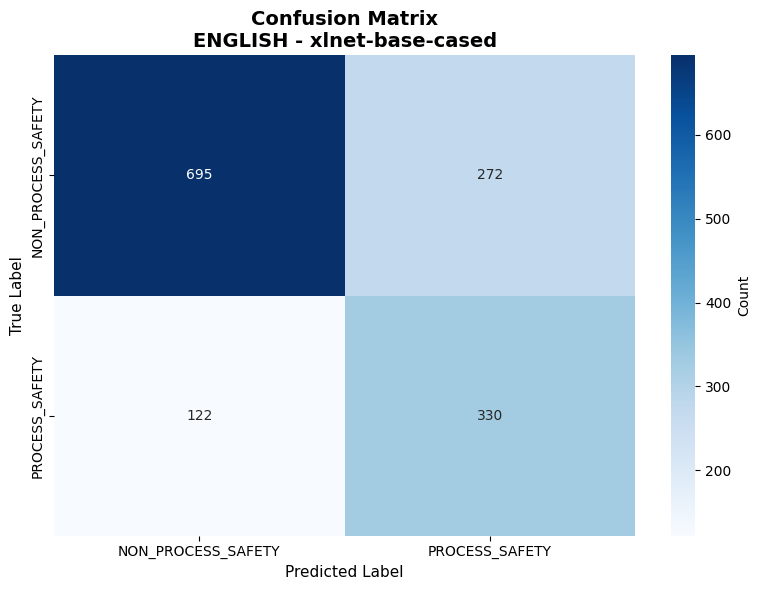


Training SVM: GERMANY | Model: xlnet-base-cased
Training samples: 18268
Test samples: 4568

Training LinearSVC (max 300s)...
Training completed in 34.11s

Accuracy: 0.7419
F1 Score (weighted): 0.7827
F1 Score (macro): 0.6129

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9460    0.7495    0.8364      4020
    Process Safety     0.2719    0.6861    0.3894       548

          accuracy                         0.7419      4568
         macro avg     0.6089    0.7178    0.6129      4568
      weighted avg     0.8651    0.7419    0.7827      4568


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_germany_xlnet_base_cased.png


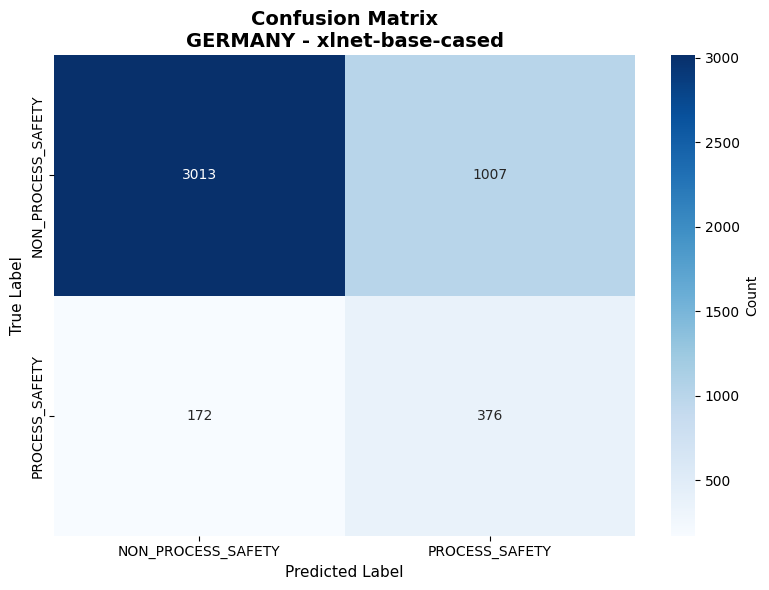


Training SVM: NETHERLANDS | Model: xlnet-base-cased
Training samples: 2534
Test samples: 634

Training LinearSVC (max 300s)...
Training completed in 31.03s

Accuracy: 0.6672
F1 Score (weighted): 0.6755
F1 Score (macro): 0.6355

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7902    0.7011    0.7430       435
    Process Safety     0.4758    0.5930    0.5280       199

          accuracy                         0.6672       634
         macro avg     0.6330    0.6471    0.6355       634
      weighted avg     0.6915    0.6672    0.6755       634


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_netherlands_xlnet_base_cased.png


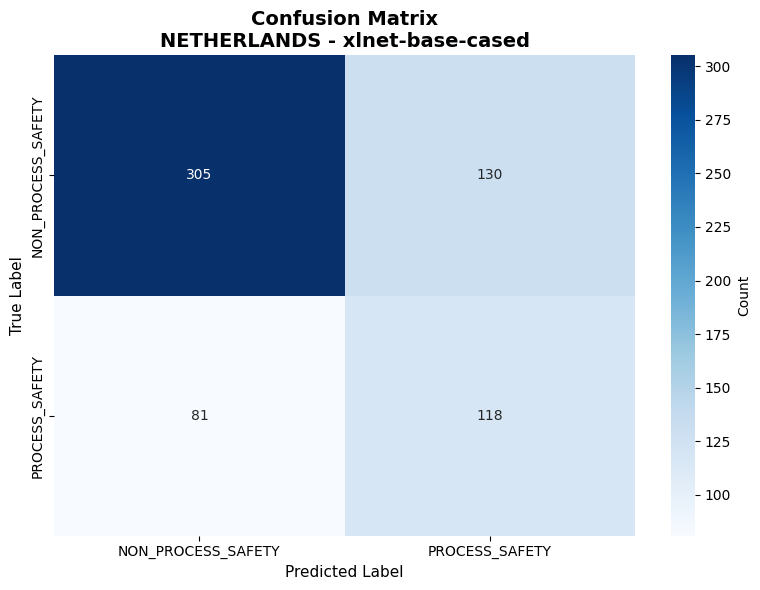


Training SVM: SWEDEN | Model: xlnet-base-cased
Training samples: 16680
Test samples: 4171

Training LinearSVC (max 300s)...
Training completed in 69.86s

Accuracy: 0.7631
F1 Score (weighted): 0.8181
F1 Score (macro): 0.5681

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9680    0.7710    0.8583      3882
    Process Safety     0.1761    0.6574    0.2778       289

          accuracy                         0.7631      4171
         macro avg     0.5720    0.7142    0.5681      4171
      weighted avg     0.9131    0.7631    0.8181      4171


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_sweden_xlnet_base_cased.png


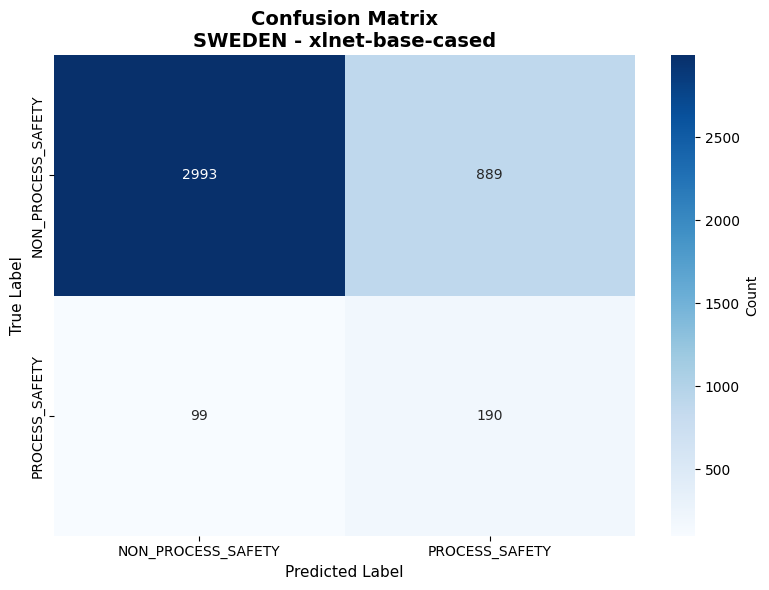


Training SVM: UK | Model: xlnet-base-cased
Training samples: 5615
Test samples: 1404

Training LinearSVC (max 300s)...
Training completed in 10.63s

Accuracy: 0.7158
F1 Score (weighted): 0.7236
F1 Score (macro): 0.6917

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8371    0.7266    0.7780       962
    Process Safety     0.5378    0.6923    0.6053       442

          accuracy                         0.7158      1404
         macro avg     0.6875    0.7095    0.6917      1404
      weighted avg     0.7429    0.7158    0.7236      1404


Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2/cm_uk_xlnet_base_cased.png


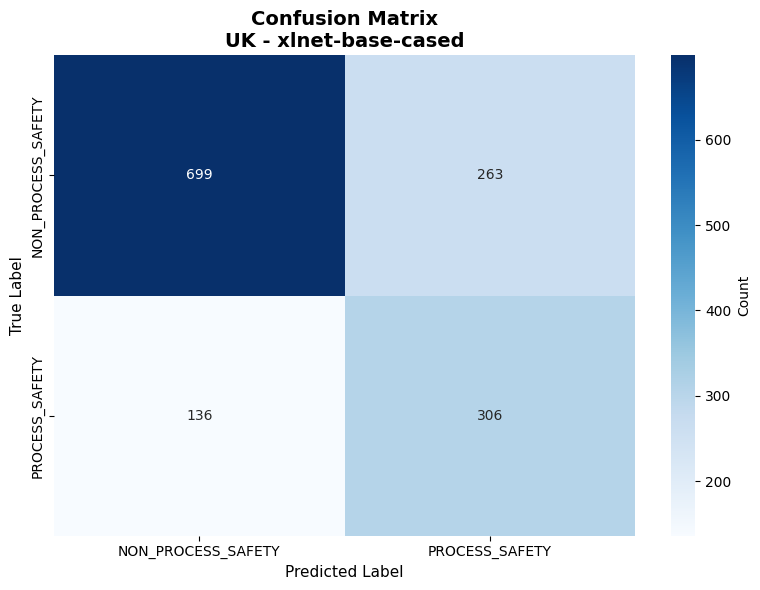


 Processing complete xlnet-base-cased

################################################################################
FINAL SUMMARY
################################################################################

DETAILED RESULTS TABLE
    dataset                 model  accuracy  f1_weighted  f1_macro  precision_non_ps  recall_non_ps  f1_non_ps  support_non_ps  precision_ps  recall_ps  f1_ps  support_ps  training_time  subsampled
    english       bert-base-cased    0.7963       0.8003    0.7753            0.8826         0.8087     0.8440             967        0.6529     0.7699 0.7066         452           9.51       False
    germany       bert-base-cased    0.7631       0.7995    0.6359            0.9523         0.7694     0.8511            4020        0.2977     0.7172 0.4208         548          57.40       False
netherlands       bert-base-cased    0.7571       0.7623    0.7314            0.8557         0.7770     0.8145             435        0.5941     0.7136 0.6484        

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time
from multiprocessing import Process, Queue
import signal

# ============================================================
# Configuration
# ============================================================

DATA_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/By_Country/"
EMBEDDINGS_BASE_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_2"
RESULTS_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_2"
CHECKPOINT_FILE = "/home/azureuser/cloudfiles/code/Users/M02555/_iteration_2/checkpoint.json"

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Model configurations
MODELS = {
    'bert-base-cased': 'bert-base-cased',
    'bert-large-cased': 'bert-large-cased',
    'roberta-base': 'roberta-base',
    'roberta-large': 'roberta-large',
    'distilbert-base-cased': 'distilbert-base-cased',
    'xlnet-base-cased': 'xlnet-base-cased'
}

# Datasets to skip
SKIP_DATASETS = [
    'RW_ACTUALS_Hungary.csv',
    'RW_ACTUALS_International.csv',
    'RW_ACTUALS_Russia.csv',
    'RW_ACTUALS_UAE.csv'
]

# Timeout and memory management settings
MAX_PROCESSING_TIME = 3600 * 3  # 3 hours in seconds
BATCH_SIZE = 4  # Reduce to prevent memory issues
SVM_TIMEOUT = 300  # 5 minutes timeout for SVM training
MAX_SAMPLES_SVM = 60000  # Limit samples for large datasets 

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

# ============================================================
# Functions
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=4):
    """Generate BERT embeddings for a list of texts with memory management"""
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'cuda':
            torch.cuda.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)


def process_dataset(csv_file, model_name, model_key, tokenizer, model):
    """Process a single CSV dataset and save embeddings"""
    # Extract dataset name from filename
    filename = os.path.basename(csv_file)
    dataset_name = filename.replace('RW_ACTUALS_', '').replace('.csv', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name} | Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset
    df = pd.read_csv(csv_file)
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\nWARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_short_name = model_name.replace('/', '_')
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name)
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings (save both full and subset)
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_short_name}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory after processing
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return pkl_file


def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_name = metadata['model']
    model_key = metadata.get('model_key', model_name)
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    # Use faster LinearSVC instead of SVC with timeout protection
    try:
        from sklearn.svm import LinearSVC
        from sklearn.metrics import precision_recall_fscore_support
        
        print(f"\nTraining LinearSVC (max {SVM_TIMEOUT}s)...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create visualization
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            cbar_kws={'label': 'Count'}
        )
        
        # Create safe filename
        model_short = model_name.replace('/', '_').replace('-', '_')
        plt.title(f'Confusion Matrix\n{dataset_name.upper()} - {model_key}', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=11)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'cm_{dataset_name}_{model_short}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\nConfusion matrix saved to: {plot_path}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': model_name,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            # Non-Process Safety (class 0) metrics
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            # Process Safety (class 1) metrics
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\nERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise


# ============================================================
# Main Execution
# ============================================================

print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)

# Get all CSV files and filter out skipped datasets
all_csv_files = glob.glob(os.path.join(DATA_DIR, 'RW_ACTUALS_*.csv'))
csv_files = [f for f in all_csv_files if os.path.basename(f) not in SKIP_DATASETS]

print(f"\nFound {len(all_csv_files)} total datasets")
print(f"Skipping {len(SKIP_DATASETS)} datasets:")
for skip in SKIP_DATASETS:
    print(f" {skip}")
print(f"\nProcessing {len(csv_files)} datasets")
print(f"Found {len(MODELS)} models to use")
print(f"Total combinations: {len(csv_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"Already processed: {len(processed_items)} combinations")

# Track all results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        print(f"Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for csv_file in csv_files:
            dataset_name = os.path.basename(csv_file).replace('RW_ACTUALS_', '').replace('.csv', '').lower()
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\nSkipping already processed: {dataset_name} with {model_key}")
                model_short_name = model_name.replace('/', '_')
                pkl_file = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name, 
                                       f'{dataset_name}_{model_short_name}_embeddings.pkl')
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            # Check timeout
            elapsed_time = time.time() - start_time
            if elapsed_time > MAX_PROCESSING_TIME:
                print(f"\nReached time limit ({MAX_PROCESSING_TIME/60:.1f} minutes).")
                print(f"Resume by running this cell again - checkpoint saved.")
                break
            
            try:
                pkl_file = process_dataset(csv_file, model_name, model_key, tokenizer, model)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Checkpoint saved. Progress: {len(processed_items)}/{len(csv_files) * len(MODELS)}")
                
            except Exception as e:
                print(f"✗ ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f"ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f"\n Processing complete {model_key}")
        
    except Exception as e:
        print(f"\nERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display DETAILED results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    
    # Format the detailed table
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps'
    ]
    
    # Check which columns exist
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    
    if 'training_time' in results_df.columns:
        display_cols.append('training_time')
    if 'subsampled' in results_df.columns:
        display_cols.append('subsampled')
    
    # Create a formatted display DataFrame
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns for better display
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save detailed results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'all_models_svm_detailed_results.csv')
    results_df.to_csv(summary_file, index=False)
    print(f"\nDetailed results saved to: {summary_file}")
    
    # Create a formatted classification report style table
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING MODEL (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best by F1 for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Results by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())
        
        # Results by dataset
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY DATASET")
        print(f"{'='*80}")
        dataset_stats = results_df.groupby('dataset')[['accuracy', 'f1_weighted', 'f1_macro',
                                                         'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(dataset_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(csv_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print("ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)
print("PIPELINE COMPLETE")
print("#"*80)